# **YOLO 모델 사용**

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
!pip install ultralytics -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.4 requires langchain-core<2.0.0,>=1.0.0, but you have langchain-core 0.3.77 which is incompatible.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.11.3 which is incompatible.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.3 which is incompatible.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.3 which is incompatible.
tensorflow-intel 2.15.0 requires tensorboard<2.16,>=2.15, but you have tensorboard 2.20.0 which is incompatible.


## (2) 라이브러리 불러오기

In [2]:
from ultralytics import settings, YOLO
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video

## (3) YOLO 설정

* 파일 경로 설정

In [14]:
# 현재 세팅을 확인해 봅시다.
settings

{'settings_version': '0.0.6',
 'datasets_dir': 'C:\\Users\\USER\\Documents\\GitHub\\AIVLE_School\\(7주차) 시각 지능과 멀티모달 AI\\datasets',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': 'e93724c3a62b829fe2022931d0c4e07c6e9e5bbc21bb08e52bb2b401c0a189fa',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

In [15]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = '/content/'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': 'e93724c3a62b829fe2022931d0c4e07c6e9e5bbc21bb08e52bb2b401c0a189fa',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델 사용

## (1) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [16]:
model = YOLO(model='yolo11n.pt', task='detect')

## (2) 모델 사용 : 이미지

아래 이미지에 대해서 객체 탐지를 해 봅시다.

![이미지](https://images.pexels.com/photos/139303/pexels-photo-139303.jpeg)


In [24]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# image_path = 'https://images.pexels.com/photos/139303/pexels-photo-139303.jpeg'
image_path = './data/pexels-photo-139303.jpeg'

results = model.predict(
    source=image_path,
    device=device
)

results[0].show()  # 탐지된 객체 출력


image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\pexels-photo-139303.jpeg: 448x640 11 persons, 8 cars, 2 traffic lights, 14.0ms
Speed: 2.9ms preprocess, 14.0ms inference, 17.4ms postprocess per image at shape (1, 3, 448, 640)


## (3)실습
* 다양한 사진을 찾아서 object detection 해 봅시다.

In [28]:
image_path = './data/dog_bicycle.jpg'
results = model.predict(
    source=image_path,
    device=device
)
results[0].show()  # 탐지된 객체 출력


image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\dog_bicycle.jpg: 480x640 1 bicycle, 1 car, 1 truck, 1 dog, 57.8ms
Speed: 2.0ms preprocess, 57.8ms inference, 3.6ms postprocess per image at shape (1, 3, 480, 640)


## (4) 객체탐지 결과 열어보기

In [29]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [30]:
print(type(results))
print(len(results))

<class 'list'>
1


In [31]:
type(results[0])

ultralytics.engine.results.Results

In [32]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [33]:
results[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [34]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16.,  1.,  2.,  7.], device='cuda:0')
conf: tensor([0.9144, 0.9123, 0.5514, 0.4651], device='cuda:0')
data: tensor([[ 88.5467, 145.8407, 209.2782, 362.1552,   0.9144,  16.0000],
        [ 84.9481,  92.3064, 380.5979, 281.0046,   0.9123,   1.0000],
        [315.8460,  50.8885, 463.6281, 115.0359,   0.5514,   2.0000],
        [315.2479,  50.5531, 463.4650, 114.8583,   0.4651,   7.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (386, 515)
shape: torch.Size([4, 6])
xywh: tensor([[148.9124, 253.9979, 120.7315, 216.3145],
        [232.7730, 186.6555, 295.6498, 188.6982],
        [389.7371,  82.9622, 147.7820,  64.1474],
        [389.3564,  82.7057, 148.2171,  64.3051]], device='cuda:0')
xywhn: tensor([[0.2892, 0.6580, 0.2344, 0.5604],
        [0.4520, 0.4836, 0.5741, 0.4889],
        [0.7568, 0.2149, 0.2870, 0.1662],
        [0.7560, 0.2143, 0.2878, 0.1666]], device='cuda:0')
xyxy: tensor([[ 88.5467, 145.840

In [35]:
for box in results[0].boxes:
    x_min, y_min, x_max, y_max = box.xyxy[0]  # 좌표
    conf = box.conf[0]
    cn = results[0].names[int(box.cls[0])]  # 클래스 이름
    print(f"좌표: {x_min}, {y_min}, {x_max}, {y_max} | conf. : {conf} | class : {cn}")

좌표: 88.54666137695312, 145.84066772460938, 209.27818298339844, 362.1551513671875 | conf. : 0.914400041103363 | class : dog
좌표: 84.94807434082031, 92.30638122558594, 380.5979309082031, 281.0046081542969 | conf. : 0.912303626537323 | class : bicycle
좌표: 315.8460388183594, 50.88851547241211, 463.6280822753906, 115.03593444824219 | conf. : 0.5513567328453064 | class : car
좌표: 315.24786376953125, 50.55312728881836, 463.4649963378906, 114.85826110839844 | conf. : 0.46510347723960876 | class : truck


## (5) 모델사용 : 동영상

* sample.mp4 파일을 업로드 합니다.

In [ ]:
# colab 파일 업로드
from google.colab import files
uploaded = files.upload()

* 동영상 객체 탐지 실행

In [41]:
# 동영상 객체 탐지 실행 및 결과 저장
results = model.predict("./data/sample.mp4", save=True)  # 결과 자동 저장


WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 2 cats, 58.5ms
video 1/1 (frame 2/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 2 cats, 13.5ms
video 1/1 (frame 3/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 2 cats, 14.9ms
video 1/1 (frame 4/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 2 

In [42]:
# 탐지된 동영상 결과 경로 확인
os.listdir("runs/detect/predict/")

['sample.avi']

* 콜랩에서 영상 play를 위한 세팅

In [ ]:
# 영상 코덱 설치
!apt-get install -y ffmpeg

In [ ]:
# AVI to MP4로 변환 (YOLO 탐지 결과 파일명에 맞게 수정)
input_video_path = "runs/detect/predict/sample.avi"  # YOLO 탐지 결과 파일명
output_video_path = "runs/detect/predict/video_converted.mp4"

# FFmpeg를 사용하여 변환 (코덱: libx264)
!ffmpeg -i {input_video_path} -vcodec libx264 {output_video_path}

* 영상 paly

In [ ]:
# YOLO 탐지 결과 동영상 재생
Video("runs/detect/predict/video_converted.mp4", embed=True)

# 3.Confidence Score, IoU

## (1) 이미지 탐지 : default

In [36]:
# 기본 설정(conf=0.25, iou=0.45)
image_path = 'https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력


image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\2018011700908_0.jpg: 320x640 4 cats, 5 dogs, 61.1ms
Speed: 1.0ms preprocess, 61.1ms inference, 7.3ms postprocess per image at shape (1, 3, 320, 640)
Results saved to C:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\runs\detect\predict


## (2) Confidence 값 조정

In [37]:
high_conf = model(image_path, conf=0.7)  # 신뢰도 증가
low_conf = model(image_path, conf=0.1)   # 신뢰도 감소


Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\2018011700908_0.jpg: 320x640 1 cat, 1 dog, 13.7ms
Speed: 1.8ms preprocess, 13.7ms inference, 2.4ms postprocess per image at shape (1, 3, 320, 640)

Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\2018011700908_0.jpg: 320x640 9 cats, 7 dogs, 18.4ms
Speed: 1.7ms preprocess, 18.4ms inference, 16.1ms postprocess per image at shape (1, 3, 320, 640)


* 탐색 결과

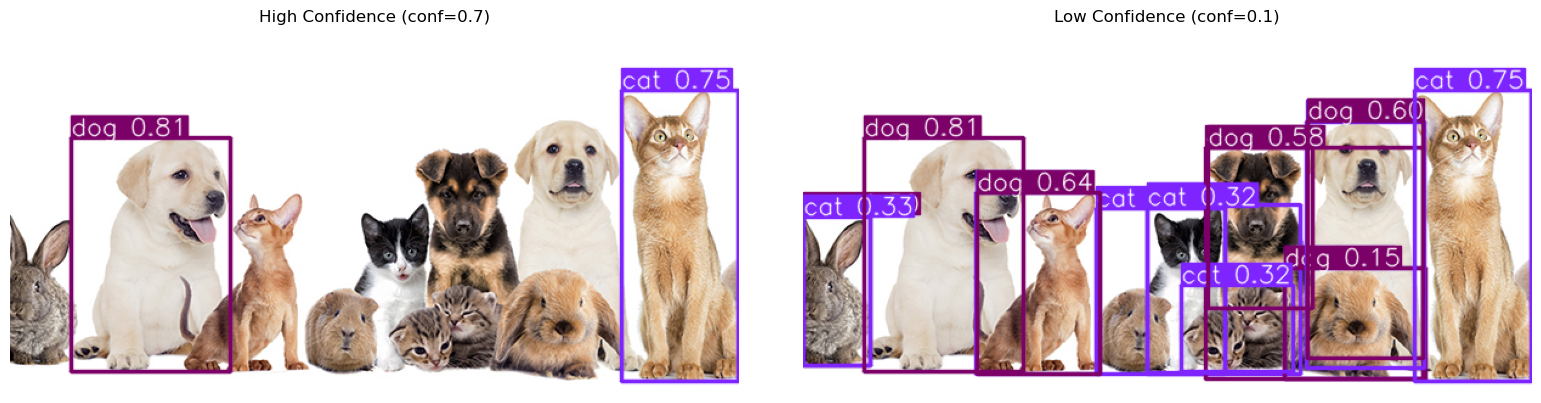

In [38]:
# Matplotlib 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 결과를 NumPy 배열로 변환하여 Matplotlib에 표시 (BGR → RGB 변환 포함)
axes[0].imshow(cv2.cvtColor(high_conf[0].plot(), cv2.COLOR_BGR2RGB))  # 높은 신뢰도
axes[0].set_title("High Confidence (conf=0.7)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(low_conf[0].plot(), cv2.COLOR_BGR2RGB))  # 낮은 신뢰도
axes[1].set_title("Low Confidence (conf=0.1)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## (3) IoU 임계 값 조정

In [39]:
high_iou = model(image_path, iou=0.7)   # IoU 증가
low_iou = model(image_path, iou=0.01)    # IoU 감소


Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\2018011700908_0.jpg: 320x640 4 cats, 5 dogs, 15.0ms
Speed: 1.4ms preprocess, 15.0ms inference, 10.6ms postprocess per image at shape (1, 3, 320, 640)

Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\2018011700908_0.jpg: 320x640 3 cats, 2 dogs, 15.5ms
Speed: 1.9ms preprocess, 15.5ms inference, 7.5ms postprocess per image at shape (1, 3, 320, 640)


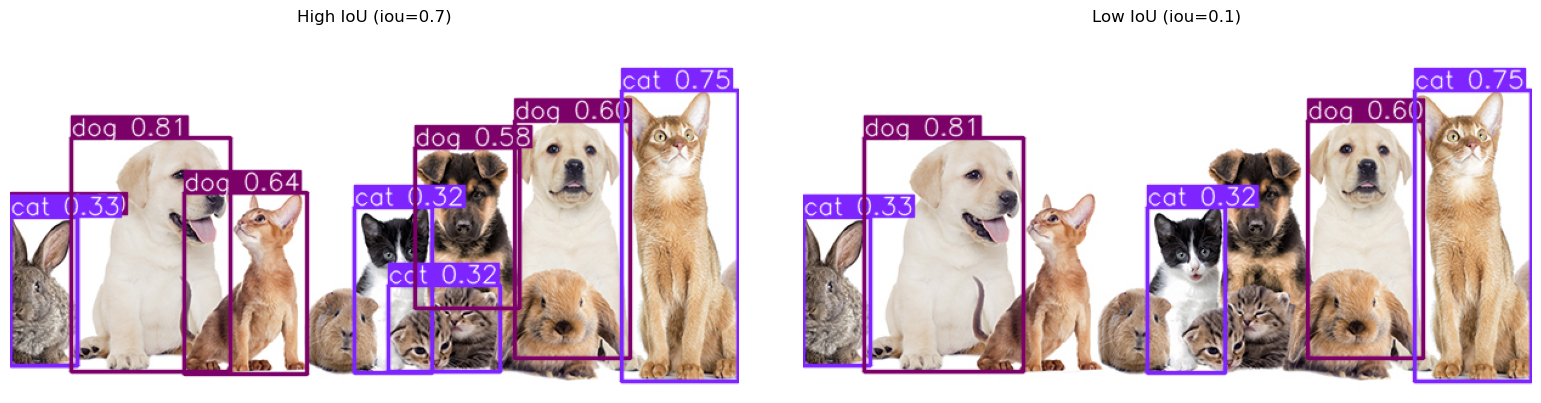

In [40]:
# Matplotlib 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 결과를 NumPy 배열로 변환하여 Matplotlib에 표시 (BGR → RGB 변환 포함)
axes[0].imshow(cv2.cvtColor(high_iou[0].plot(), cv2.COLOR_BGR2RGB))  # 높은 IoU
axes[0].set_title("High IoU (iou=0.7)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(low_iou[0].plot(), cv2.COLOR_BGR2RGB))  # 낮은 IoU
axes[1].set_title("Low IoU (iou=0.1)")
axes[1].axis("off")

plt.tight_layout()
plt.show()